# 06. Extra LPIPS Experiments: Backbones, Shifts, and Distortions

This notebook goes beyond the original reconstruction notebooks and focuses on LPIPS itself as a metric.

Questions answered here:

- Do `alex`, `vgg`, and `squeeze` LPIPS backbones behave differently?
- How do LPIPS and MSE respond to blur, noise, downsampling, and spatial shift?
- Is LPIPS more sensitive to some changes than MSE?


In [ ]:
!pip install torch torchvision lpips matplotlib pandas pillow seaborn

import io
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, Subset

import lpips

sns.set_theme(style="whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "generated_figures"
FIG_DIR.mkdir(exist_ok=True)
print("Using device:", DEVICE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.0 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# Reproducibility helps make LPIPS-vs-MSE comparisons fair.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
STL10_CLASSES = CIFAR10_CLASSES

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def to_lpips_range(x):
    return x * 2.0 - 1.0


def psnr(pred, target):
    mse = torch.mean((pred - target) ** 2, dim=(1, 2, 3))
    return 10.0 * torch.log10(1.0 / (mse + 1e-8))


def build_transform(image_size: int):
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
    ])


def degrade_image(image: torch.Tensor, mode: str):
    image = image.clone()
    if mode == "identity":
        return image
    if mode == "gaussian_noise":
        noise = 0.08 * torch.randn_like(image)
        return torch.clamp(image + noise, 0.0, 1.0)
    if mode == "blur":
        return TF.gaussian_blur(image, kernel_size=[5, 5], sigma=[1.2, 1.2])
    if mode == "downsample":
        h, w = image.shape[-2:]
        small = TF.resize(image, [max(8, h // 4), max(8, w // 4)], antialias=True)
        return TF.resize(small, [h, w], antialias=True)
    if mode == "shift":
        return torch.roll(image, shifts=(2, 2), dims=(1, 2))
    raise ValueError(f"Unknown degradation mode: {mode}")


class ReconstructionWrapper(Dataset):
    def __init__(self, base_dataset, degradation="identity"):
        self.base_dataset = base_dataset
        self.degradation = degradation

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]
        image = sample[0] if isinstance(sample, tuple) else sample
        degraded = degrade_image(image, self.degradation)
        return degraded, image


class RepeatedSingleImageDataset(Dataset):
    def __init__(self, image: torch.Tensor, repeats=256, degradation="identity"):
        self.image = image
        self.repeats = repeats
        self.degradation = degradation

    def __len__(self):
        return self.repeats

    def __getitem__(self, idx):
        return degrade_image(self.image, self.degradation), self.image


def get_dataset(dataset_name: str, image_size: int):
    transform = build_transform(image_size)
    name = dataset_name.upper()
    if name == "CIFAR10":
        return torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "CIFAR100":
        return torchvision.datasets.CIFAR100(root=str(DATA_DIR), train=True, download=True, transform=transform)
    if name == "STL10":
        return torchvision.datasets.STL10(root=str(DATA_DIR), split="train", download=True, transform=transform)
    if name == "CELEBA":
        return torchvision.datasets.CelebA(root=str(DATA_DIR), split="train", download=True, transform=transform)
    raise ValueError(f"Unsupported dataset: {dataset_name}")


def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return [int(x) for x in dataset.targets]
    if hasattr(dataset, "labels"):
        return [int(x) for x in dataset.labels]
    return None


def filter_by_class(dataset, dataset_name: str, class_name: str, max_items=1000):
    if class_name == "all":
        return dataset
    targets = get_targets(dataset)
    if targets is None:
        raise ValueError(f"Dataset {dataset_name} does not expose simple class labels for filtering.")
    if dataset_name.upper() == "CIFAR10":
        class_index = CIFAR10_CLASSES.index(class_name)
    elif dataset_name.upper() == "STL10":
        class_index = STL10_CLASSES.index(class_name)
    else:
        raise ValueError(f"Class filtering not set up for {dataset_name}.")
    indices = [i for i, target in enumerate(targets) if target == class_index][:max_items]
    return Subset(dataset, indices)


def train_two_models(train_loader, epochs=5, lpips_net="vgg"):
    base_model = ConvAutoencoder().to(DEVICE)
    model_lpips = ConvAutoencoder().to(DEVICE)
    model_mse = ConvAutoencoder().to(DEVICE)
    model_lpips.load_state_dict(base_model.state_dict())
    model_mse.load_state_dict(base_model.state_dict())

    optimizer_lpips = optim.Adam(model_lpips.parameters(), lr=1e-4)
    optimizer_mse = optim.Adam(model_mse.parameters(), lr=1e-4)
    lpips_loss = lpips.LPIPS(net=lpips_net).to(DEVICE).eval()
    mse_loss = nn.MSELoss()

    history = {"epoch": [], "lpips_train_loss": [], "mse_train_loss": []}
    for epoch in range(1, epochs + 1):
        model_lpips.train()
        model_mse.train()
        running_lpips = 0.0
        running_mse = 0.0
        batches = 0

        for degraded, clean in train_loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)

            optimizer_lpips.zero_grad()
            pred_lpips = model_lpips(degraded)
            loss_lp = lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean()
            loss_lp.backward()
            optimizer_lpips.step()

            optimizer_mse.zero_grad()
            pred_mse = model_mse(degraded)
            loss_mse = mse_loss(pred_mse, clean)
            loss_mse.backward()
            optimizer_mse.step()

            running_lpips += loss_lp.item()
            running_mse += loss_mse.item()
            batches += 1

        history["epoch"].append(epoch)
        history["lpips_train_loss"].append(running_lpips / batches)
        history["mse_train_loss"].append(running_mse / batches)
        print(f"Epoch {epoch:02d} | LPIPS: {history['lpips_train_loss'][-1]:.4f} | MSE: {history['mse_train_loss'][-1]:.4f}")

    return model_lpips, model_mse, pd.DataFrame(history), lpips_loss, mse_loss


def evaluate_models(model_lpips, model_mse, loader, lpips_loss, mse_loss):
    model_lpips.eval()
    model_mse.eval()
    rows = []
    with torch.no_grad():
        for degraded, clean in loader:
            degraded = degraded.to(DEVICE)
            clean = clean.to(DEVICE)
            pred_lpips = model_lpips(degraded)
            pred_mse = model_mse(degraded)
            rows.append({
                "lpips_model_lpips": lpips_loss(to_lpips_range(pred_lpips), to_lpips_range(clean)).mean().item(),
                "mse_model_lpips": lpips_loss(to_lpips_range(pred_mse), to_lpips_range(clean)).mean().item(),
                "lpips_model_mse": mse_loss(pred_lpips, clean).item(),
                "mse_model_mse": mse_loss(pred_mse, clean).item(),
                "lpips_model_psnr": psnr(pred_lpips, clean).mean().item(),
                "mse_model_psnr": psnr(pred_mse, clean).mean().item(),
            })
    return pd.DataFrame(rows).mean().to_frame(name="value")


def show_reconstructions(model_lpips, model_mse, loader, title, n=5):
    degraded, clean = next(iter(loader))
    degraded = degraded.to(DEVICE)
    clean = clean.to(DEVICE)
    with torch.no_grad():
        pred_lpips = model_lpips(degraded).cpu()
        pred_mse = model_mse(degraded).cpu()
    degraded = degraded.cpu()
    clean = clean.cpu()

    n = min(n, degraded.size(0))
    plt.figure(figsize=(3 * n, 8))
    for i in range(n):
        plt.subplot(4, n, i + 1)
        plt.imshow(degraded[i].permute(1, 2, 0))
        plt.title("Input")
        plt.axis("off")

        plt.subplot(4, n, n + i + 1)
        plt.imshow(clean[i].permute(1, 2, 0))
        plt.title("Target")
        plt.axis("off")

        plt.subplot(4, n, 2 * n + i + 1)
        plt.imshow(pred_lpips[i].permute(1, 2, 0))
        plt.title("LPIPS")
        plt.axis("off")

        plt.subplot(4, n, 3 * n + i + 1)
        plt.imshow(pred_mse[i].permute(1, 2, 0))
        plt.title("MSE")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
DATASET_NAME = "CIFAR10"
CLASS_NAME = "frog"
IMAGE_SIZE = 128
MAX_IMAGES = 8
SHIFT_PIXELS = [0, 1, 2, 4, 6, 8]
DISTORTIONS = ["identity", "gaussian_noise", "blur", "downsample", "shift"]


In [ ]:
# Collect a small batch of images for metric-only experiments.
dataset = get_dataset(DATASET_NAME, IMAGE_SIZE)
dataset = filter_by_class(dataset, DATASET_NAME, CLASS_NAME, max_items=MAX_IMAGES)

images = []
for idx in range(min(MAX_IMAGES, len(dataset))):
    sample = dataset[idx]
    image = sample[0] if isinstance(sample, tuple) else sample
    images.append(image)
images = torch.stack(images).to(DEVICE)
print("Loaded images:", images.shape)

lpips_models = {
    "alex": lpips.LPIPS(net="alex").to(DEVICE).eval(),
    "vgg": lpips.LPIPS(net="vgg").to(DEVICE).eval(),
    "squeeze": lpips.LPIPS(net="squeeze").to(DEVICE).eval(),
}
mse_loss = nn.MSELoss()


100%|██████████| 170M/170M [00:04<00:00, 42.6MB/s]


Loaded images: torch.Size([8, 3, 128, 128])
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 169MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 193MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 47.2MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth


In [ ]:
# Distortion sensitivity experiment.
rows = []
for distortion in DISTORTIONS:
    distorted = torch.stack([degrade_image(img.cpu(), distortion) for img in images.cpu()]).to(DEVICE)
    row = {"distortion": distortion}
    for net_name, lp_model in lpips_models.items():
        row[f"lpips_{net_name}"] = lp_model(to_lpips_range(distorted), to_lpips_range(images)).mean().item()
    row["mse"] = mse_loss(distorted, images).item()
    row["psnr"] = psnr(distorted, images).mean().item()
    rows.append(row)

distortion_df = pd.DataFrame(rows)
distortion_df


,distortion,lpips_alex,lpips_vgg,lpips_squeeze,mse,psnr
0,identity,0.000000,0.000000,0.000000,0.000000,80.000000
1,gaussian_noise,0.792676,0.549322,0.793816,0.006038,22.203403
2,blur,0.028602,0.022966,0.016856,0.000058,42.589676
3,downsample,0.080725,0.088511,0.059456,0.000529,33.102119
4,shift,0.078853,0.199241,0.072959,0.005099,23.166265


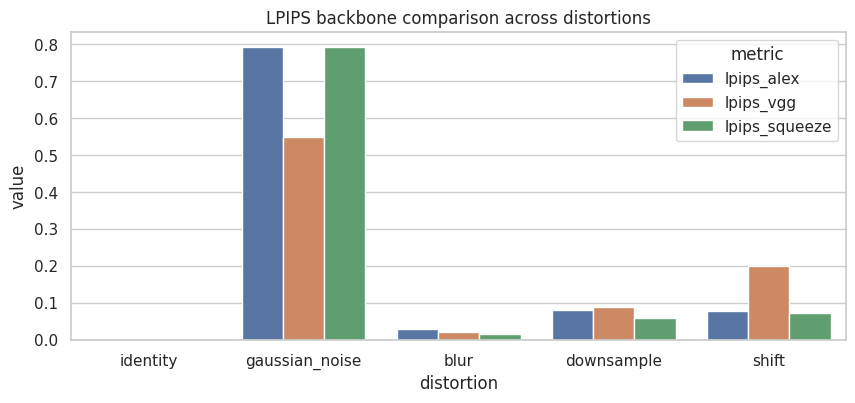

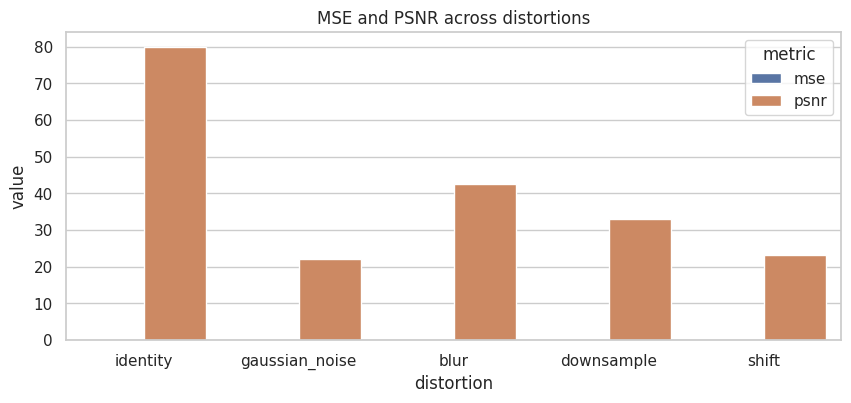

In [ ]:
plt.figure(figsize=(10, 4))
plot_df = distortion_df.melt(id_vars="distortion", value_vars=["lpips_alex", "lpips_vgg", "lpips_squeeze"], var_name="metric", value_name="value")
sns.barplot(data=plot_df, x="distortion", y="value", hue="metric")
plt.title("LPIPS backbone comparison across distortions")
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=distortion_df.melt(id_vars="distortion", value_vars=["mse", "psnr"], var_name="metric", value_name="value"), x="distortion", y="value", hue="metric")
plt.title("MSE and PSNR across distortions")
plt.show()


In [ ]:
# Shift curve experiment: increase spatial shift gradually.
shift_rows = []
for pixels in SHIFT_PIXELS:
    shifted = torch.roll(images, shifts=(pixels, pixels), dims=(2, 3))
    shift_rows.append({
        "shift_pixels": pixels,
        "lpips_alex": lpips_models["alex"](to_lpips_range(shifted), to_lpips_range(images)).mean().item(),
        "lpips_vgg": lpips_models["vgg"](to_lpips_range(shifted), to_lpips_range(images)).mean().item(),
        "lpips_squeeze": lpips_models["squeeze"](to_lpips_range(shifted), to_lpips_range(images)).mean().item(),
        "mse": mse_loss(shifted, images).item(),
    })

shift_df = pd.DataFrame(shift_rows)
shift_df


,shift_pixels,lpips_alex,lpips_vgg,lpips_squeeze,mse
0,0,0.000000,0.000000,0.000000,0.000000
1,1,0.046219,0.093112,0.057845,0.001801
2,2,0.078853,0.199241,0.072959,0.005099
3,4,0.151483,0.312114,0.107538,0.014032
4,6,0.215667,0.400993,0.154981,0.023446
5,8,0.250529,0.446288,0.189128,0.031717


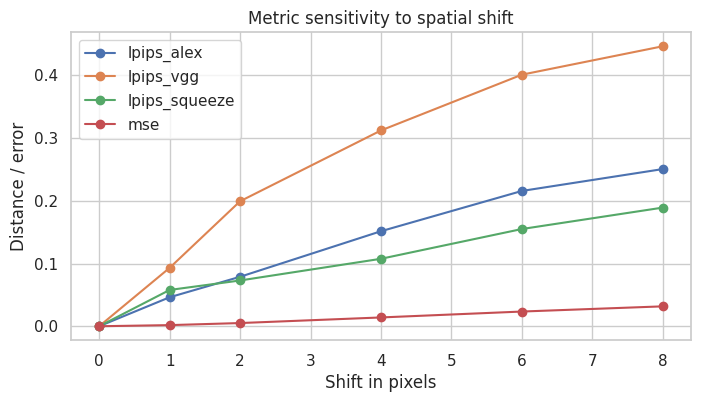

In [ ]:
plt.figure(figsize=(8, 4))
for column in ["lpips_alex", "lpips_vgg", "lpips_squeeze", "mse"]:
    plt.plot(shift_df["shift_pixels"], shift_df[column], marker="o", label=column)
plt.xlabel("Shift in pixels")
plt.ylabel("Distance / error")
plt.title("Metric sensitivity to spatial shift")
plt.legend()
plt.show()


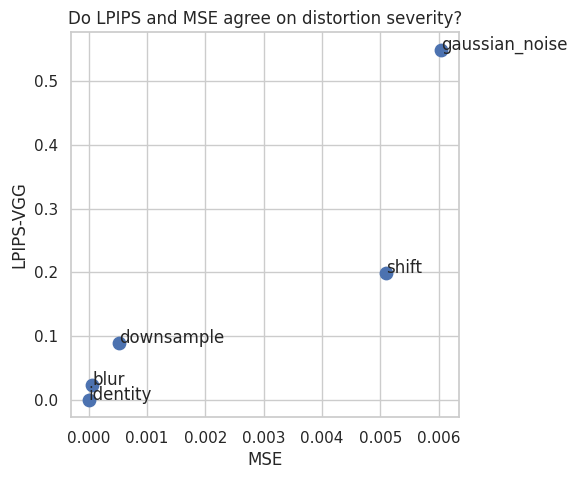

In [ ]:
# Correlation view: do LPIPS and MSE rank distortions similarly?
plt.figure(figsize=(5, 5))
plt.scatter(distortion_df["mse"], distortion_df["lpips_vgg"], s=80)
for _, row in distortion_df.iterrows():
    plt.text(row["mse"], row["lpips_vgg"], row["distortion"])
plt.xlabel("MSE")
plt.ylabel("LPIPS-VGG")
plt.title("Do LPIPS and MSE agree on distortion severity?")
plt.show()


## Notes

- This notebook studies LPIPS as a metric, not only as a training loss.
- If LPIPS reacts differently from MSE to shift or blur, that is a strong discussion point for your report.
- Comparing `alex`, `vgg`, and `squeeze` gives you an extra dimension that was not covered in the original notebooks.
